In [27]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_recall_fscore_support
from sklearn.metrics import f1_score,roc_auc_score
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,VotingClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score
import time

In [28]:
df = pd.read_csv("E:/szls/labelled1.csv")

In [29]:
df.Label.value_counts()

0    19200
4     4340
2     2270
1      880
3      360
Name: Label, dtype: int64

In [30]:
X = df.drop(['Label'],axis=1)
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size = 0.2, random_state = 0) #shuffle=False

In [31]:
pd.Series(y_train).value_counts()

0    15374
4     3459
2     1810
1      697
3      300
Name: Label, dtype: int64

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      3826
           1       1.00      1.00      1.00       183
           2       0.88      0.78      0.83       460
           3       1.00      1.00      1.00        60
           4       0.97      0.82      0.89       881

    accuracy                           0.94      5410
   macro avg       0.96      0.92      0.94      5410
weighted avg       0.94      0.94      0.94      5410

Accuracy of GradientBoostingClassifier: 0.9426987060998152
Precision of GradientBoostingClassifier: 0.943010692639642
Recall of GradientBoostingClassifier: 0.9426987060998152
Average F1 of GradientBoostingClassifier: 0.941153681838637
F1 of GradientBoostingClassifier for each type of attack: [0.96263232 1.         0.82758621 1.         0.8909427 ]


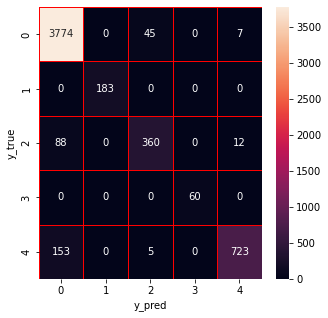

CPU times: total: 4.67 s
Wall time: 5.17 s


In [32]:
%%time
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
print(classification_report(y_test,y_pred))
print("Accuracy of GradientBoostingClassifier: "+ str(accuracy_score(y_test, y_pred)))
print("Precision of GradientBoostingClassifier: "+ str(precision_score(y_test, y_pred, average='weighted')))
print("Recall of GradientBoostingClassifier: "+ str(recall_score(y_test, y_pred, average='weighted')))
print("Average F1 of GradientBoostingClassifier: "+ str(f1_score(y_test, y_pred, average='weighted')))
print("F1 of GradientBoostingClassifier for each type of attack: "+ str(f1_score(y_test, y_pred, average=None)))
lg_f1=f1_score(y_test, y_pred, average=None)

# Plot the confusion matrix
cm=confusion_matrix(y_test,y_pred)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

Accuracy of RF: 0.9979667282809612
Precision of RF: 0.9979689249992172
Recall of RF: 0.9979667282809612
F1-score of RF: 0.9979660800050422
F1 of RandomForestClassifier for each type of attack: [0.96263232 1.         0.82758621 1.         0.8909427 ]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       1.00      1.00      1.00       183
           2       0.99      1.00      1.00       460
           3       1.00      1.00      1.00        60
           4       1.00      0.99      1.00       881

    accuracy                           1.00      5410
   macro avg       1.00      1.00      1.00      5410
weighted avg       1.00      1.00      1.00      5410



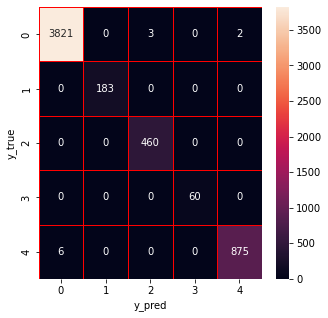

In [33]:
rf = RandomForestClassifier(n_estimators = 71, min_samples_leaf = 1, max_depth = 46, min_samples_split = 9, max_features = 20, criterion = 'entropy')
rf.fit(X_train,y_train) 
rf_score=rf.score(X_test,y_test)
y_predict=rf.predict(X_test)
y_true=y_test
print('Accuracy of RF: '+ str(rf_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of RF: '+(str(precision)))
print('Recall of RF: '+(str(recall)))
print('F1-score of RF: '+(str(fscore)))
print("F1 of RandomForestClassifier for each type of attack: "+ str(f1_score(y_test, y_pred, average=None)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3826
           1       1.00      1.00      1.00       183
           2       0.94      0.97      0.95       460
           3       1.00      1.00      1.00        60
           4       1.00      0.94      0.97       881

    accuracy                           0.98      5410
   macro avg       0.98      0.98      0.98      5410
weighted avg       0.98      0.98      0.98      5410

Accuracy of LightGBM: 0.9824399260628466
Precision of LightGBM: 0.9826776152335595
Recall of LightGBM: 0.9824399260628466
Average F1 of LightGBM: 0.9823858009951482
F1 of LightGBM for each type of attack: [0.98803641 1.         0.95391211 1.         0.96785506]


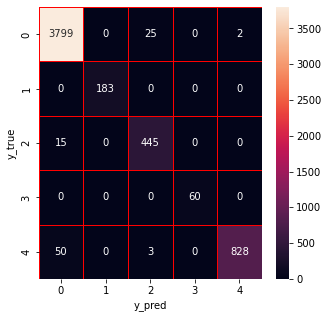

CPU times: total: 8.42 s
Wall time: 722 ms


In [34]:
%%time
# Train the LightGBM algorithm
import lightgbm as lgb
lg = lgb.LGBMClassifier()
lg.fit(X_train, y_train)
y_pred = lg.predict(X_test)
print(classification_report(y_test,y_pred))
print("Accuracy of LightGBM: "+ str(accuracy_score(y_test, y_pred)))
print("Precision of LightGBM: "+ str(precision_score(y_test, y_pred, average='weighted')))
print("Recall of LightGBM: "+ str(recall_score(y_test, y_pred, average='weighted')))
print("Average F1 of LightGBM: "+ str(f1_score(y_test, y_pred, average='weighted')))
print("F1 of LightGBM for each type of attack: "+ str(f1_score(y_test, y_pred, average=None)))
lg_f1=f1_score(y_test, y_pred, average=None)

# Plot the confusion matrix
cm=confusion_matrix(y_test,y_pred)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [35]:
gb_train=gb.predict(X_train)
gb_test=gb.predict(X_test)
rf_train=rf.predict(X_train)
rf_test=rf.predict(X_test)
lg_train=lg.predict(X_train)
lg_test=lg.predict(X_test)

In [36]:
base_predictions_train = pd.DataFrame( {
    ' GradientBoosting': gb_train.ravel(),
        'RandomForest': rf_train.ravel(),
     'LGBM': lg_train.ravel(),
    })
base_predictions_train.head(5)

,GradientBoosting,RandomForest,LGBM
0,2,2,2
1,0,0,0
2,4,4,4
3,0,0,0
4,3,3,3


In [37]:
gb_train=gb_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
lg_train=lg_train.reshape(-1, 1)
gb_test=gb_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
lg_test=lg_test.reshape(-1, 1)

In [38]:
gb_train.shape

(21640, 1)

In [39]:
x_train = np.concatenate(( gb_train, lg_train, rf_train), axis=1)
x_test = np.concatenate(( gb_test, lg_test, rf_test), axis=1)

Accuracy of Stacking: 0.9979667282809612
Precision of Stacking: 0.9979689249992172
Recall of Stacking: 0.9979667282809612
F1-score of Stacking: 0.9979660800050422
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       1.00      1.00      1.00       183
           2       0.99      1.00      1.00       460
           3       1.00      1.00      1.00        60
           4       1.00      0.99      1.00       881

    accuracy                           1.00      5410
   macro avg       1.00      1.00      1.00      5410
weighted avg       1.00      1.00      1.00      5410



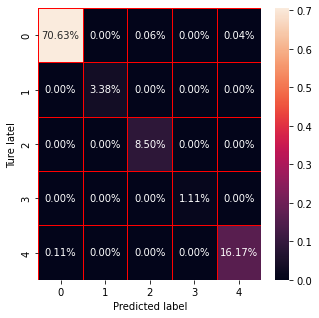

In [41]:
import xgboost as xgb
stk = xgb.XGBClassifier().fit(x_train, y_train)
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
p1=sns.heatmap(cm/np.sum(cm),annot=True,linewidth=0.5,linecolor="red",fmt=".2%",ax=ax)
plt.xlabel("Predicted label")
plt.ylabel("Ture latel")
plt.show()
s1 = p1.get_figure()
s1.savefig('HeatMap.jpg',dpi=300,bbox_inches='tight')
s1 = p1.get_figure()
s1.savefig('C:/Users/lenovo/Desktop/HeatMap3.jpg',dpi=300,bbox_inches='tight')